In [ ]:
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scvelo as scv

import os
import sys
import gc

sys.path.append('../')
from scdisentangle.train.tools import set_seed
import local_tools as lt

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

# Set seed

In [3]:
seed_nb = 42
set_seed(seed_nb)

ic| 'Setting seed to', seed: 42


In [4]:
save_path = f'{FIG_ROOT}/Prostate/cell_transition/ood_transition'
os.makedirs(save_path, exist_ok=True)

# Construct castration and regeneration velocity adatas

In [5]:
def get_heatmap(timepoints, short_names):
    # extract Ly6d per L2 cell for each time-point
    ly6d_per_tp = {}
    
    for tp in timepoints:
        adata = sc.read_h5ad(f'../predictions/{tp}.h5ad')
        
        ly6d_idx = adata.var_names.get_loc('Ly6d')
        mask_l2 = adata.obs['predType'] == 'Epi_Luminal_2Psca'
        ly6d_per_tp[tp] = np.asarray(adata.X[mask_l2, ly6d_idx]).flatten()
        del adata; gc.collect()
    
    # compute pair-wise velocity
    n_tp = len(timepoints)
    heatmap_mean = np.full((n_tp, n_tp), np.nan)
    
    for i in range(n_tp):
        for j in range(i + 1, n_tp):
            velocity = ly6d_per_tp[timepoints[j]] - ly6d_per_tp[timepoints[i]]
            heatmap_mean[i, j] = velocity.mean()

    df_mean = pd.DataFrame(heatmap_mean, index=short_names, columns=short_names)
    return df_mean

In [6]:
def plot_half_heatmap(df, ax, title):
    data = df.values
    vmax = np.nanmax(np.abs(data))
    norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    n = len(df)

    ax.imshow(data, cmap='RdBu_r', norm=norm, aspect='equal')

    for i in range(n):
        for j in range(n):
            val = data[i, j]
            if np.isnan(val):
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             facecolor='white', edgecolor='#e0e0e0', lw=0.5))
            else:
                color = 'white' if abs(val) > vmax * 0.55 else 'black'
                ax.text(j, i, f'{val:+.2f}', ha='center', va='center',
                        fontsize=7, fontweight='bold', color=color)

    ax.set_xticks(range(n))
    ax.set_xticklabels(df.columns, fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(df.index, fontsize=8)
    ax.set_xlabel('Future', fontsize=9)
    ax.set_ylabel('Current', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    return norm

In [7]:
regeneration_time_points = [
        'T04_Cast_Day28',
        'T05_Regen_Day1', 'T06_Regen_Day2', 
        'T07_Regen_Day3', 'T08_Regen_Day7',
        'T09_Regen_Day14', 'T10_Regen_Day28'
        ]

castration_time_points = [
        'T01_Cast_Day1', 'T02_Cast_Day7', 
        'T03_Cast_Day14', 'T04_Cast_Day28',
        ]

In [8]:
castration_heatmap = get_heatmap(
    timepoints=castration_time_points,
    short_names=['C1', 'C7', 'C14', 'C28']
)

regeneration_heatmap = get_heatmap(
    timepoints=regeneration_time_points,
    short_names=['C28', 'R1', 'R2', 'R3', 'R7', 'R14', 'R28']
)

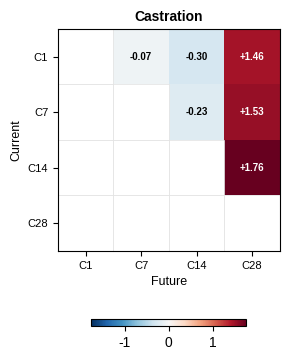

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))

plot_half_heatmap(castration_heatmap, ax, 'Castration')
vmax = np.nanmax(np.abs(castration_heatmap.values))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = fig.colorbar(sm, ax=[ax], location='bottom',
                    fraction=0.06, pad=0.22, shrink=0.5)

plt.savefig(f'{save_path}/Ly6d_castration.png', dpi=600)
plt.savefig(f'{save_path}/Ly6d_castration.svg', dpi=600)

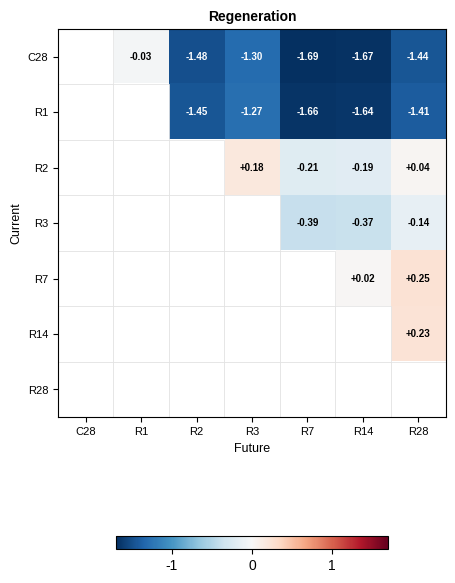

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

plot_half_heatmap(regeneration_heatmap, ax, 'Regeneration')
vmax = np.nanmax(np.abs(regeneration_heatmap.values))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = fig.colorbar(sm, ax=[ax], location='bottom',
                    fraction=0.06, pad=0.22, shrink=0.5)

plt.savefig(f'{save_path}/Ly6d_regeneration.png', dpi=600)
plt.savefig(f'{save_path}/Ly6d_regeneration.svg', dpi=600)

In [11]:
castration_heatmap

,C1,C7,C14,C28
C1,NaN,-0.07106,-0.298544,1.460314
C7,NaN,NaN,-0.227485,1.531374
C14,NaN,NaN,NaN,1.758858
C28,NaN,NaN,NaN,NaN


In [12]:
regeneration_heatmap

,C28,R1,R2,R3,R7,R14,R28
C28,NaN,-0.03351,-1.479103,-1.302047,-1.689870,-1.671711,-1.442994
R1,NaN,NaN,-1.445593,-1.268536,-1.656360,-1.638201,-1.409484
R2,NaN,NaN,NaN,0.177056,-0.210767,-0.192608,0.036108
R3,NaN,NaN,NaN,NaN,-0.387824,-0.369665,-0.140948
R7,NaN,NaN,NaN,NaN,NaN,0.018159,0.246876
R14,NaN,NaN,NaN,NaN,NaN,NaN,0.228717
R28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
